# Group 1 - 3850 Business Forecasting EDA and Simple Model

This file contains the EDA and Simple Model. The models were seperated into different files for ease of running.

In [1]:
# load packages 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.holtwinters import (
    SimpleExpSmoothing,
    Holt,
    ExponentialSmoothing
)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

In [2]:
# load data set
sales_data = pd.read_csv("sales_data.csv")

## Data Preprocessing

In [3]:
# convert to date time
sales_data["Date"] = pd.to_datetime(sales_data["Date"])
sales_data = sales_data.sort_values("Date")
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                76000 non-null  datetime64[ns]
 1   Store ID            76000 non-null  object        
 2   Product ID          76000 non-null  object        
 3   Category            76000 non-null  object        
 4   Region              76000 non-null  object        
 5   Inventory Level     76000 non-null  int64         
 6   Units Sold          76000 non-null  int64         
 7   Units Ordered       76000 non-null  int64         
 8   Price               76000 non-null  float64       
 9   Discount            76000 non-null  int64         
 10  Weather Condition   76000 non-null  object        
 11  Promotion           76000 non-null  int64         
 12  Competitor Pricing  76000 non-null  float64       
 13  Seasonality         76000 non-null  object        


In [4]:
# assess distribution
sales_data["Date"].min(), sales_data["Date"].max(), sales_data["Date"].nunique()

(Timestamp('2022-01-01 00:00:00'), Timestamp('2024-01-30 00:00:00'), 760)

### Observations per date check

In [5]:
# data information
obs_per_date = sales_data.groupby("Date").size()
obs_per_date.describe()

count    760.0
mean     100.0
std        0.0
min      100.0
25%      100.0
50%      100.0
75%      100.0
max      100.0
dtype: float64

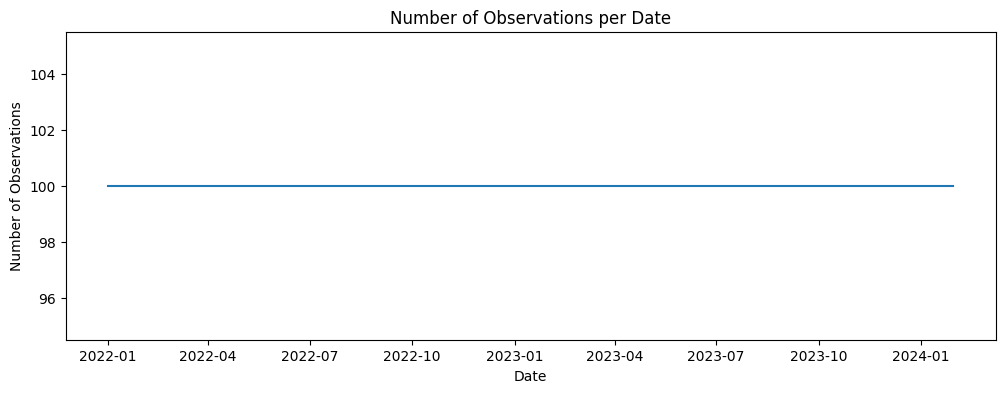

In [6]:
# observations per day plot
plt.figure(figsize=(12, 4))
plt.plot(obs_per_date.index, obs_per_date.values)
plt.title("Number of Observations per Date")
plt.xlabel("Date")
plt.ylabel("Number of Observations")
plt.show()

### Further data cleaning

In [7]:
# data cleaning of sales data 
sales_data[["Store ID", "Product ID", "Category", "Region"]].nunique()
sales_data["series_id"] = sales_data["Store ID"].astype(str) + "_" + sales_data["Product ID"].astype(str)
sales_data[["Date", "series_id", "Store ID", "Product ID", "Units Sold"]].head()
sales_data["series_id"].nunique()
series_lengths = sales_data.groupby("series_id")["Date"].nunique()
series_lengths.describe()

count    100.0
mean     760.0
std        0.0
min      760.0
25%      760.0
50%      760.0
75%      760.0
max      760.0
Name: Date, dtype: float64

All 100 unique time series's have equal length, and do not need to fill forward missing values.

### Duplicate and missing date checks

In [8]:
# duplicate check 
sales_data.duplicated().sum()
sales_data.duplicated(subset=["Date", "Store ID", "Product ID"]).sum()
date_range = pd.date_range(start=sales_data["Date"].min(), end=sales_data["Date"].max(), freq="D")
missing_dates = date_range.difference(sales_data["Date"].unique())
missing_dates
len(missing_dates)

0

No missing dates

### Duplicate Records Check

In [9]:
sales_data.duplicated().sum()

np.int64(0)

In [10]:
sales_data.duplicated(subset=["Date", "Store ID", "Product ID"]).sum()

np.int64(0)

No missing or duplicate cells 

### Invalid Numerical Values Check

In [11]:
# invalid numeric columns inspection
numeric_cols = [
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Price",
    "Discount",
    "Competitor Pricing",
    "Promotion",
    "Epidemic",
    "Demand"
]

sales_data[numeric_cols].describe()

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Competitor Pricing,Promotion,Epidemic,Demand
count,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,301.062842,88.827316,89.090645,67.726028,9.087039,69.454029,0.328947,0.200000,104.317158
std,226.510161,43.994525,162.404627,39.377899,7.475781,40.943818,0.469834,0.400003,46.964801
min,0.000000,0.000000,0.000000,4.740000,0.000000,4.290000,0.000000,0.000000,4.000000
25%,136.000000,58.000000,0.000000,31.997500,5.000000,32.620000,0.000000,0.000000,71.000000
50%,227.000000,84.000000,0.000000,64.500000,10.000000,65.700000,0.000000,0.000000,100.000000
75%,408.000000,114.000000,121.000000,95.830000,10.000000,97.932500,1.000000,0.000000,133.000000
max,2267.000000,426.000000,1616.000000,228.030000,25.000000,261.220000,1.000000,1.000000,430.000000


In [12]:
# zero check
zero_check = (sales_data[numeric_cols] == 0).sum().reset_index()
zero_check.columns = ["column", "zero_count"]
zero_check

,column,zero_count
0,Inventory Level,406
1,Units Sold,406
2,Units Ordered,47107
3,Price,0
4,Discount,17126
5,Competitor Pricing,0
6,Promotion,51000
7,Epidemic,60800
8,Demand,0


No invalid values

## Exploratory Data Analysis

In [13]:
# numeric column assessment 
numeric_cols = [
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Price",
    "Discount",
    "Competitor Pricing",
    "Promotion",
    "Epidemic",
    "Demand"
]

sales_data[numeric_cols].describe()

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Competitor Pricing,Promotion,Epidemic,Demand
count,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,301.062842,88.827316,89.090645,67.726028,9.087039,69.454029,0.328947,0.200000,104.317158
std,226.510161,43.994525,162.404627,39.377899,7.475781,40.943818,0.469834,0.400003,46.964801
min,0.000000,0.000000,0.000000,4.740000,0.000000,4.290000,0.000000,0.000000,4.000000
25%,136.000000,58.000000,0.000000,31.997500,5.000000,32.620000,0.000000,0.000000,71.000000
50%,227.000000,84.000000,0.000000,64.500000,10.000000,65.700000,0.000000,0.000000,100.000000
75%,408.000000,114.000000,121.000000,95.830000,10.000000,97.932500,1.000000,0.000000,133.000000
max,2267.000000,426.000000,1616.000000,228.030000,25.000000,261.220000,1.000000,1.000000,430.000000


Units sold mean around 88,82, with min of 0 and max of 426. Demand is generally higher than units sold, Inventory level shows substantial variation due to its high sdev. Units ordered have a median of 0, suggesting that at least half of the observations have no new units ordered, maybe showing ordering is not continuous everyday.

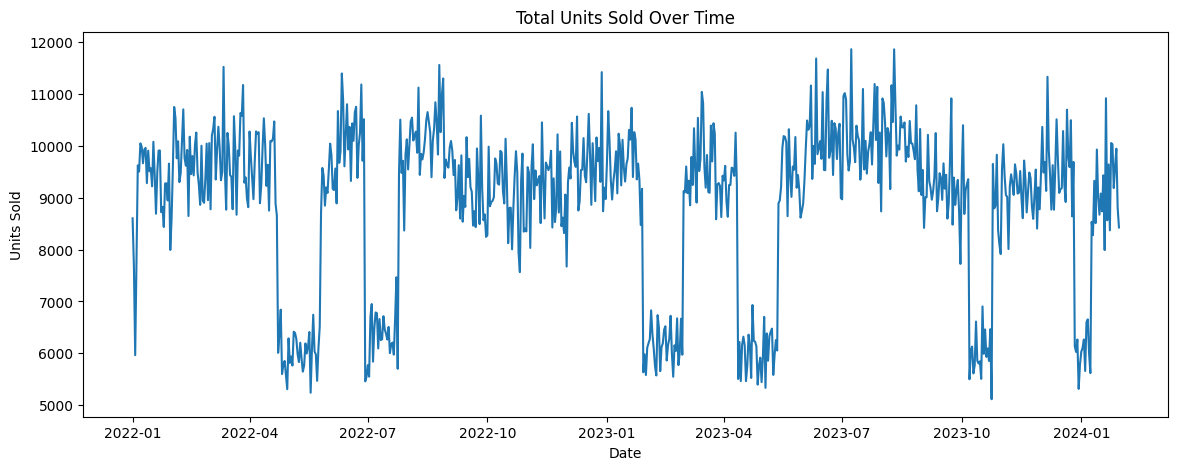

In [14]:
# daily units sold distrbution
daily_units_sold = sales_data.groupby("Date")["Units Sold"].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(daily_units_sold["Date"], daily_units_sold["Units Sold"])
plt.title("Total Units Sold Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.show()

The total units sold series shows a clear repeating seasonal pattern, with regular sharp drops followed by recovery across the full horizon. Sales usually fluctuate around 8,500–10,500 units, but fall to around 5,500–6,500 units during low-sales periods. This suggests the data is suitable for time series forecasting because it contains visible seasonality, changing short-term fluctuations, and possible structural/holiday-style effects that should be considered before modelling.

In [15]:
# target variable statistics
target = "Units Sold"

sales_data[target].agg([
    "mean",
    "std",
    "min",
    "max",
    "skew",
    "kurt"
]).round(3)

mean     88.827
std      43.995
min       0.000
max     426.000
skew      0.790
kurt      1.249
Name: Units Sold, dtype: float64

The positive skewness of 0.790 indicates a right-skewed distribution, meaning occasional high-sales observations are present. The positive kurtosis of 1.249 suggests heavier tails and possible extreme sales spikes, so outlier and seasonality checks are important before forecasting.

### Time series decomposition

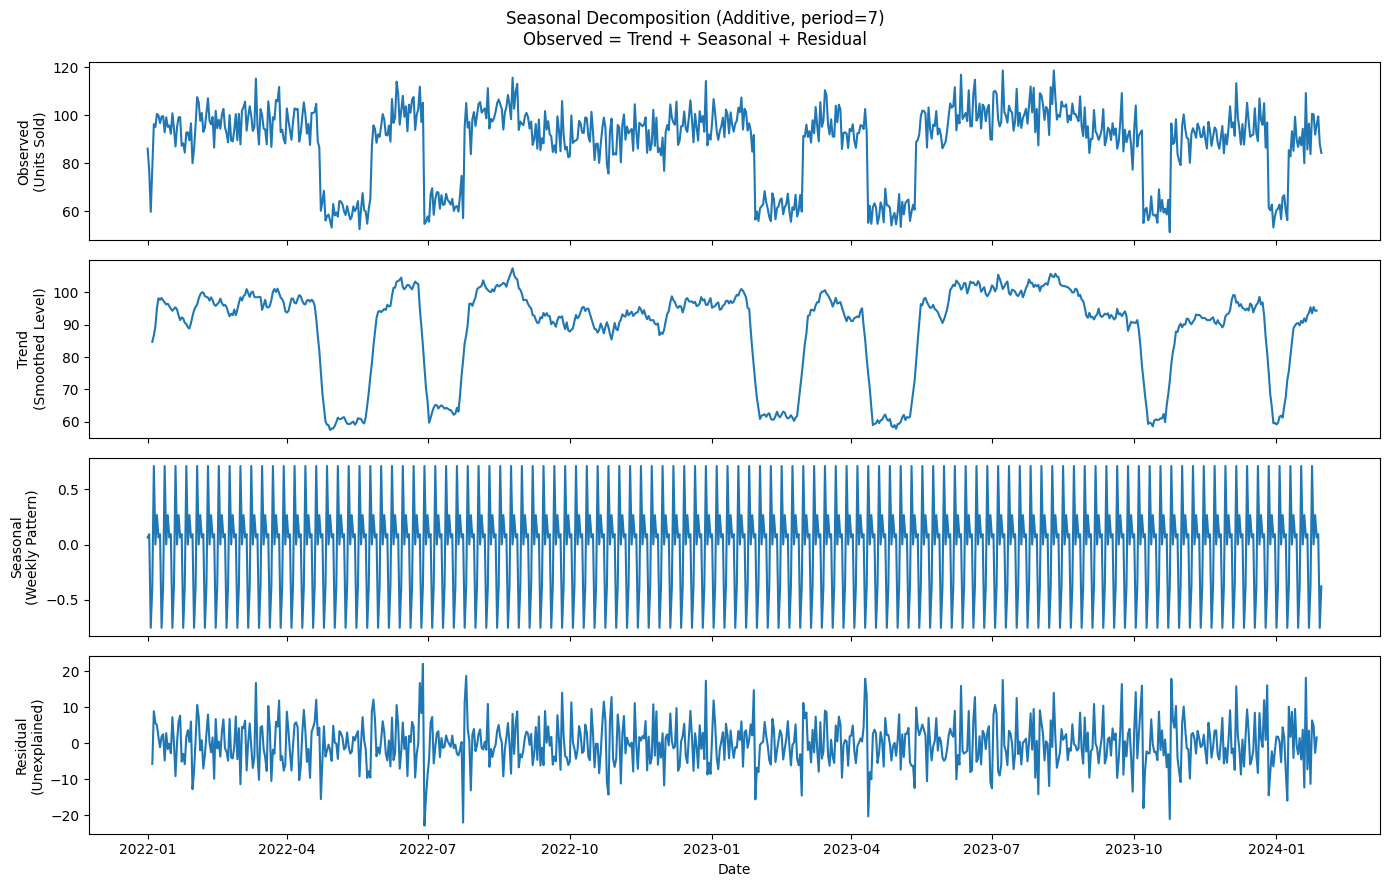

In [16]:
# time series decomposition
daily_avg_units_sold = sales_data.groupby("Date")["Units Sold"].mean()
daily_avg_units_sold = daily_avg_units_sold.asfreq("D")

decomposition = seasonal_decompose(
    daily_avg_units_sold,
    model="additive",
    period=7
)

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)

fig.suptitle(
    "Seasonal Decomposition (Additive, period=7)\nObserved = Trend + Seasonal + Residual",
    fontsize=12
)

axes[0].plot(decomposition.observed)
axes[0].set_ylabel("Observed\n(Units Sold)")

axes[1].plot(decomposition.trend)
axes[1].set_ylabel("Trend\n(Smoothed Level)")

axes[2].plot(decomposition.seasonal)
axes[2].set_ylabel("Seasonal\n(Weekly Pattern)")

axes[3].plot(decomposition.resid)
axes[3].set_ylabel("Residual\n(Unexplained)")

axes[3].set_xlabel("Date")

plt.tight_layout()
plt.show()

### ACF and PACF

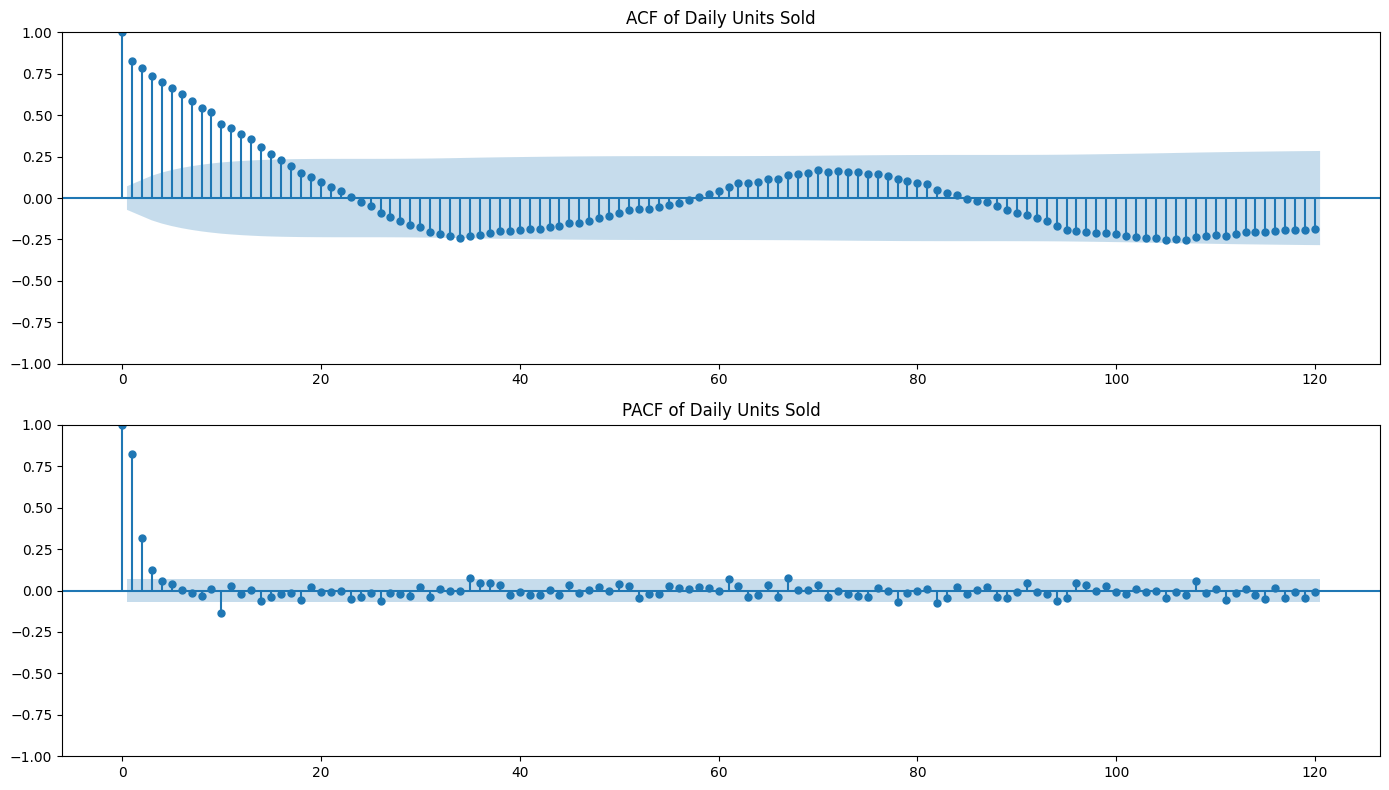

In [17]:
# Convert date column
sales_data['Date'] = pd.to_datetime(sales_data['Date'])

# Aggregate daily units sold
daily_units_sold = (
    sales_data.groupby('Date')['Units Sold']
    .sum()
)

# Plot ACF and PACF
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(daily_units_sold, lags=120, ax=axes[0])
axes[0].set_title("ACF of Daily Units Sold")

plot_pacf(
    daily_units_sold,
    lags=120,
    ax=axes[1],
    method='ywm'
)
axes[1].set_title("PACF of Daily Units Sold")

plt.tight_layout()
plt.show()

The ACF shows a slow, wave-like decay, which means Units Sold has strong time dependence and is not behaving like random noise. The repeated rise and fall pattern also suggests a seasonal or cyclical structure in the sales series. Because the ACF does not cut off quickly, the original series is likely not fully stationary and may require differencing or seasonal modelling.

The PACF shows a large significant spike at lag 1 and a smaller spike around lag 2, then most later lags become much weaker. This suggests that recent sales values, especially the previous day, are important for explaining current sales. In QBUS3850 terms, this supports considering AR-style components, especially low-order AR terms.

Overall, the ACF/PACF results suggest that Units Sold has strong autocorrelation, possible seasonality, and non-stationary behaviour, so forecasting models should not treat observations as independent. Models such as ARIMA/SARIMA, exponential smoothing, or models with seasonal components would be more suitable than a simple static average model.

### Further 'outlier' detection

In [18]:
# outlier detection
q1 = daily_units_sold.quantile(0.25)
q3 = daily_units_sold.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = daily_units_sold[(daily_units_sold < lower_bound) | (daily_units_sold > upper_bound)]

outlier_summary = pd.DataFrame({
    "Metric": [
        "Q1",
        "Q3",
        "IQR",
        "Lower Bound",
        "Upper Bound",
        "Number of Outliers",
        "Outlier Percentage",
        "Minimum Outlier",
        "Maximum Outlier"
    ],
    "Value": [
        q1,
        q3,
        iqr,
        lower_bound,
        upper_bound,
        outliers.shape[0],
        outliers.shape[0] / daily_units_sold.shape[0] * 100,
        outliers.min() if outliers.shape[0] > 0 else None,
        outliers.max() if outliers.shape[0] > 0 else None
    ]
})

outlier_summary["Value"] = outlier_summary["Value"].round(3)
outlier_summary

,Metric,Value
0,Q1,8524.000
1,Q3,9926.500
2,IQR,1402.500
3,Lower Bound,6420.250
4,Upper Bound,12030.250
5,Number of Outliers,122.000
6,Outlier Percentage,16.053
7,Minimum Outlier,5117.000
8,Maximum Outlier,6417.000


The outlier check identifies 122 outlier days, which is about 16.05% of the daily sales observations. Using the IQR rule, normal daily sales are expected to fall between 6,420.25 and 12,030.25 units. The detected outliers range from 5,117 to 6,417 units, meaning all outliers are low-sales outliers, not unusually high-sales spikes.

This matches the earlier time series plot, where Units Sold had repeated sharp drops. This also suggests the outliers are likely not random data errors, but recurring low-sales periods caused by seasonality, promotions, inventory shortages, epidemic effects, or other external conditions. Therefore, they should not be automatically removed; they should be treated as meaningful sales shocks or seasonal low-demand periods for forecasting.

## Store x Category Time Series Setup and EDA

In [19]:
df = sales_data
# store x category aggregation 
store_cat = df.groupby(['Date', 'Store ID', 'Category'])['Units Sold'].sum().reset_index()
store_cat = store_cat.sort_values(['Store ID', 'Category', 'Date'])

# exog aggregation 
exog_df = df.groupby(['Date', 'Store ID', 'Category']).agg({
    'Discount': 'mean',
    'Price':    'mean',
    'Epidemic': 'max',
}).reset_index()

#settings 
HOLDOUT = 28
SHORT_HORIZON = 5
LONG_HORIZON  = 28

print(f"Number of series: {store_cat.groupby(['Store ID', 'Category']).ngroups}")
print(f"Date range: {store_cat['Date'].min()} to {store_cat['Date'].max()}")
print(f"Holdout: {HOLDOUT} days")
print(f"Short horizon: {SHORT_HORIZON} days")
print(f"Long horizon: {LONG_HORIZON} days")

Number of series: 24
Date range: 2022-01-01 00:00:00 to 2024-01-30 00:00:00
Holdout: 28 days
Short horizon: 5 days
Long horizon: 28 days


In [20]:
print(df['Store ID'].nunique(), 'stores')
print(df['Product ID'].nunique(), 'products')
print(df['Category'].nunique(), 'categories')
print(df['Region'].nunique(), 'regions')
print(df.groupby(['Store ID', 'Product ID'])['Units Sold'].count().describe())
print(f"\nDate range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Total days: {df['Date'].nunique()}")

5 stores
20 products
5 categories
4 regions
count    100.0
mean     760.0
std        0.0
min      760.0
25%      760.0
50%      760.0
75%      760.0
max      760.0
Name: Units Sold, dtype: float64

Date range: 2022-01-01 00:00:00 to 2024-01-30 00:00:00
Total days: 760


In [21]:
print(df['Product ID'].unique())
print(df[['Product ID', 'Category']].drop_duplicates().sort_values('Category'))

['P0001' 'P0013' 'P0012' 'P0011' 'P0010' 'P0009' 'P0008' 'P0007' 'P0006'
 'P0005' 'P0004' 'P0003' 'P0002' 'P0020' 'P0019' 'P0018' 'P0017' 'P0016'
 'P0015' 'P0014']
   Product ID  Category
35      P0016  Clothing
78      P0019  Clothing
59      P0020  Clothing
2       P0003  Clothing
1       P0002  Clothing
..        ...       ...
96      P0017      Toys
40      P0001      Toys
26      P0007      Toys
99      P0020      Toys
12      P0013      Toys

[64 rows x 2 columns]


In [22]:
print(df[['Discount', 'Price', 'Epidemic']].describe())
print(df['Epidemic'].value_counts())
print(df['Discount'].value_counts())

           Discount         Price      Epidemic
count  76000.000000  76000.000000  76000.000000
mean       9.087039     67.726028      0.200000
std        7.475781     39.377899      0.400003
min        0.000000      4.740000      0.000000
25%        5.000000     31.997500      0.000000
50%       10.000000     64.500000      0.000000
75%       10.000000     95.830000      0.000000
max       25.000000    228.030000      1.000000
Epidemic
0    60800
1    15200
Name: count, dtype: int64
Discount
10    23298
0     17126
5     16918
15     6245
25     6222
20     6191
Name: count, dtype: int64


In [23]:
print(df.groupby('Category')['Units Sold'].sum().sort_values(ascending=False))
print(df.groupby('Region')['Units Sold'].sum().sort_values(ascending=False))
print(df.groupby('Store ID')['Units Sold'].sum().sort_values(ascending=False))

Category
Groceries      3127335
Clothing       1150873
Furniture       880654
Toys            834679
Electronics     757335
Name: Units Sold, dtype: int64
Region
North    2680946
South    1386126
East     1375613
West     1308191
Name: Units Sold, dtype: int64
Store ID
S002    1386126
S003    1375613
S005    1362812
S001    1318134
S004    1308191
Name: Units Sold, dtype: int64


In [24]:
store_cat = df.groupby(['Date', 'Store ID', 'Category'])['Units Sold'].sum().unstack(['Store ID', 'Category'])
print(store_cat.describe().round(0))

Store ID     S001                                            S002              \
Category Clothing Electronics Furniture Groceries   Toys Clothing Electronics   
count       760.0       760.0     760.0     760.0  760.0    760.0       760.0   
mean        313.0       234.0     260.0     624.0  303.0    452.0       249.0   
std          76.0        73.0      87.0     161.0  117.0     92.0        81.0   
min          64.0        75.0      70.0     214.0   33.0    219.0         0.0   
25%         259.0       182.0     208.0     509.0  246.0    386.0       192.0   
50%         305.0       236.0     264.0     620.0  319.0    443.0       250.0   
75%         362.0       282.0     319.0     729.0  380.0    509.0       305.0   
max         631.0       499.0     552.0    1189.0  659.0    763.0       512.0   

Store ID                             ...   S003     S004              \
Category Furniture Groceries   Toys  ...   Toys Clothing Electronics   
count        760.0     760.0  760.0  ...  760

In [25]:
print(df[['Store ID', 'Region']].drop_duplicates().sort_values('Store ID'))


   Store ID Region
0      S001  North
22     S002  South
59     S003   East
72     S004   West
99     S005  North


## Simple Model

In [26]:
store_cat = df.groupby(['Date', 'Store ID', 'Category'])['Units Sold'].sum().reset_index()
store_cat['Date'] = pd.to_datetime(store_cat['Date'])
store_cat = store_cat.sort_values(['Store ID', 'Category', 'Date'])

print(store_cat.head(20))
print(f"\nNumber of series: {store_cat.groupby(['Store ID', 'Category']).ngroups}")
print(store_cat.groupby(['Store ID', 'Category'])['Units Sold'].count().describe())

          Date Store ID  Category  Units Sold
0   2022-01-01     S001  Clothing         319
24  2022-01-02     S001  Clothing         379
48  2022-01-03     S001  Clothing         183
72  2022-01-04     S001  Clothing         201
96  2022-01-05     S001  Clothing         363
120 2022-01-06     S001  Clothing         335
144 2022-01-07     S001  Clothing         241
168 2022-01-08     S001  Clothing         269
192 2022-01-09     S001  Clothing         416
216 2022-01-10     S001  Clothing         481
240 2022-01-11     S001  Clothing         314
264 2022-01-12     S001  Clothing         430
288 2022-01-13     S001  Clothing         480
312 2022-01-14     S001  Clothing         332
336 2022-01-15     S001  Clothing         515
360 2022-01-16     S001  Clothing         336
384 2022-01-17     S001  Clothing         462
408 2022-01-18     S001  Clothing         579
432 2022-01-19     S001  Clothing         329
456 2022-01-20     S001  Clothing         224

Number of series: 24
count     24

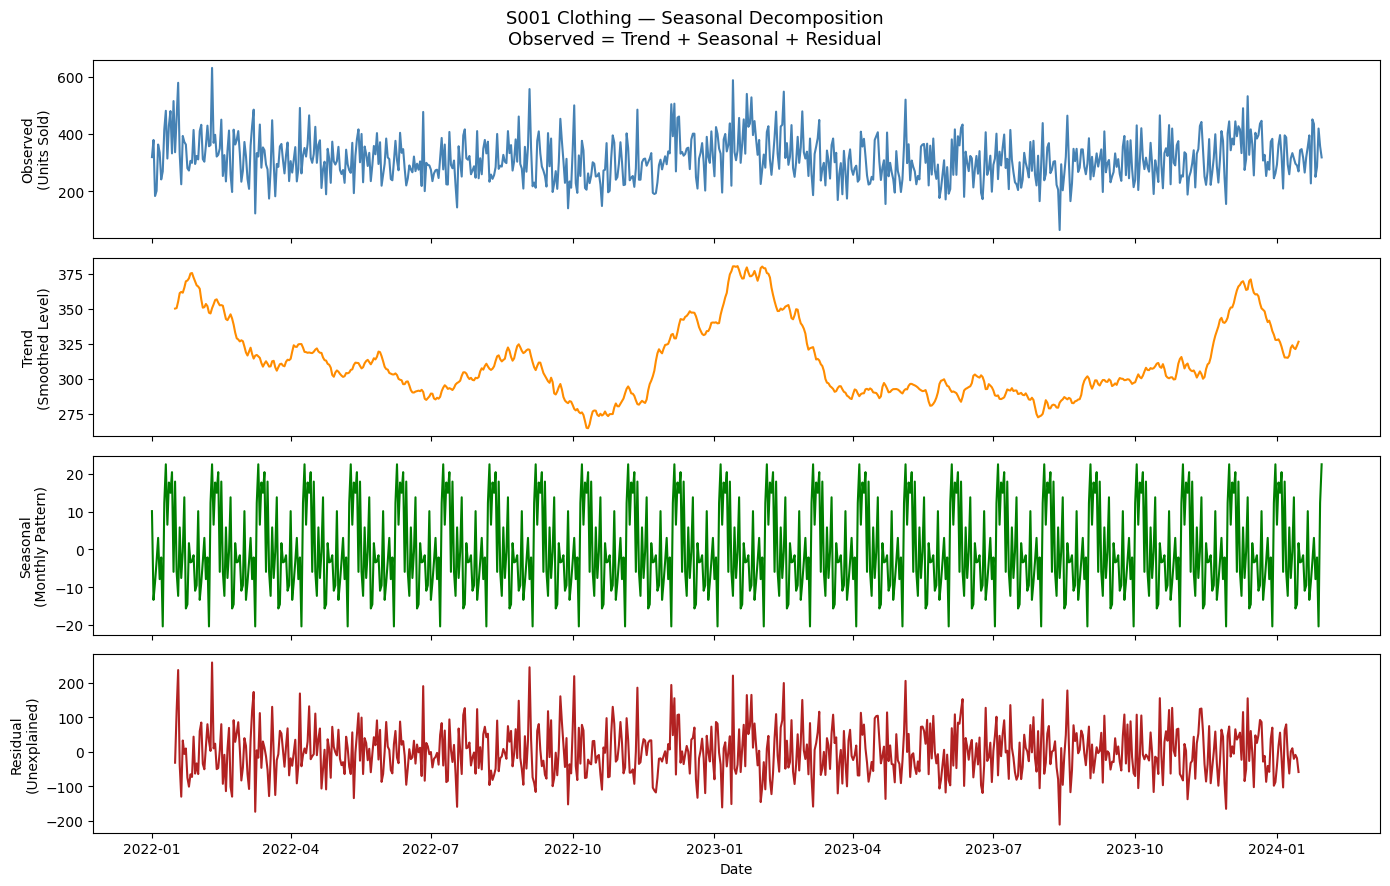

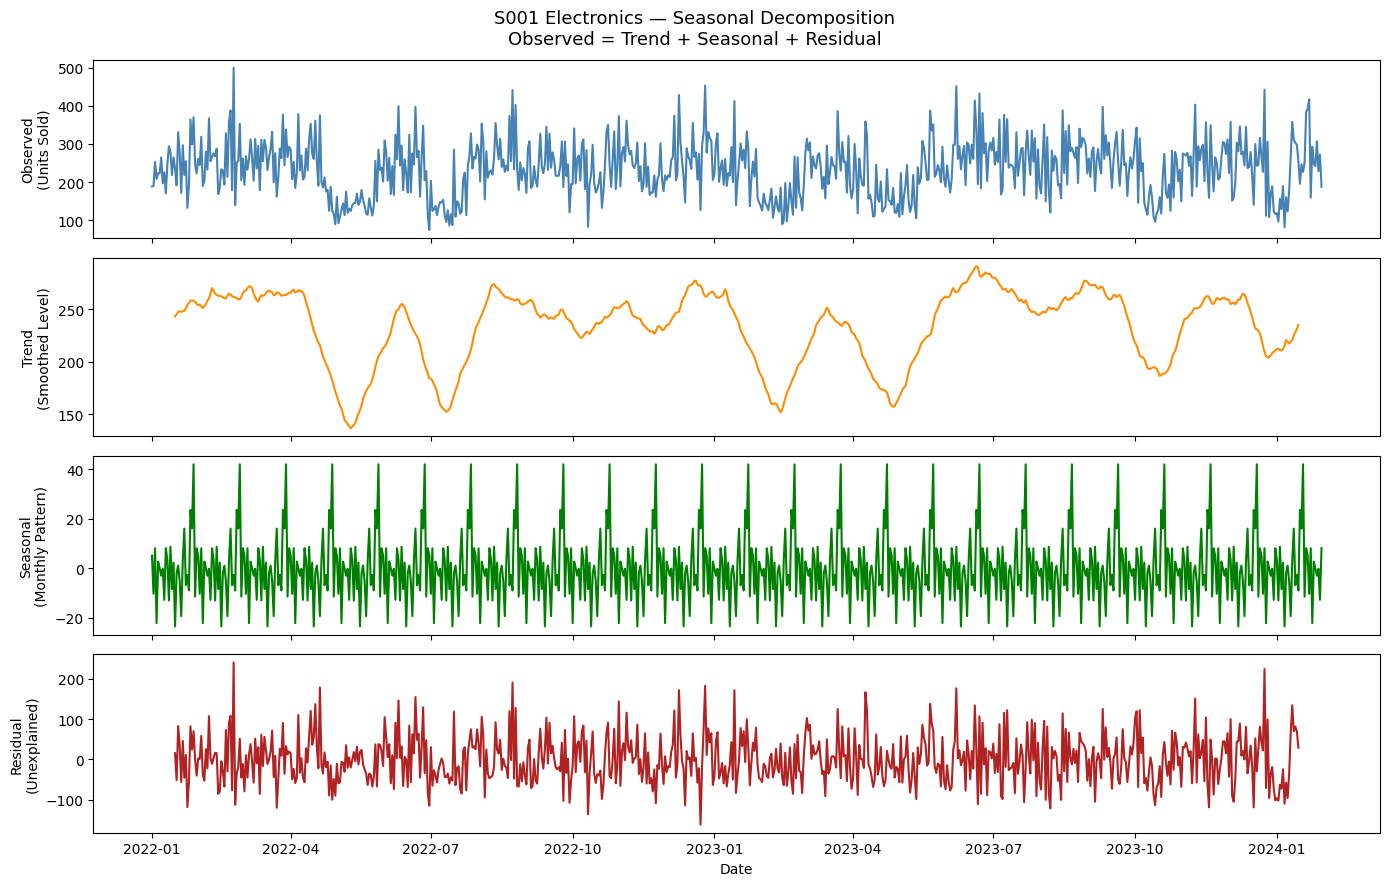

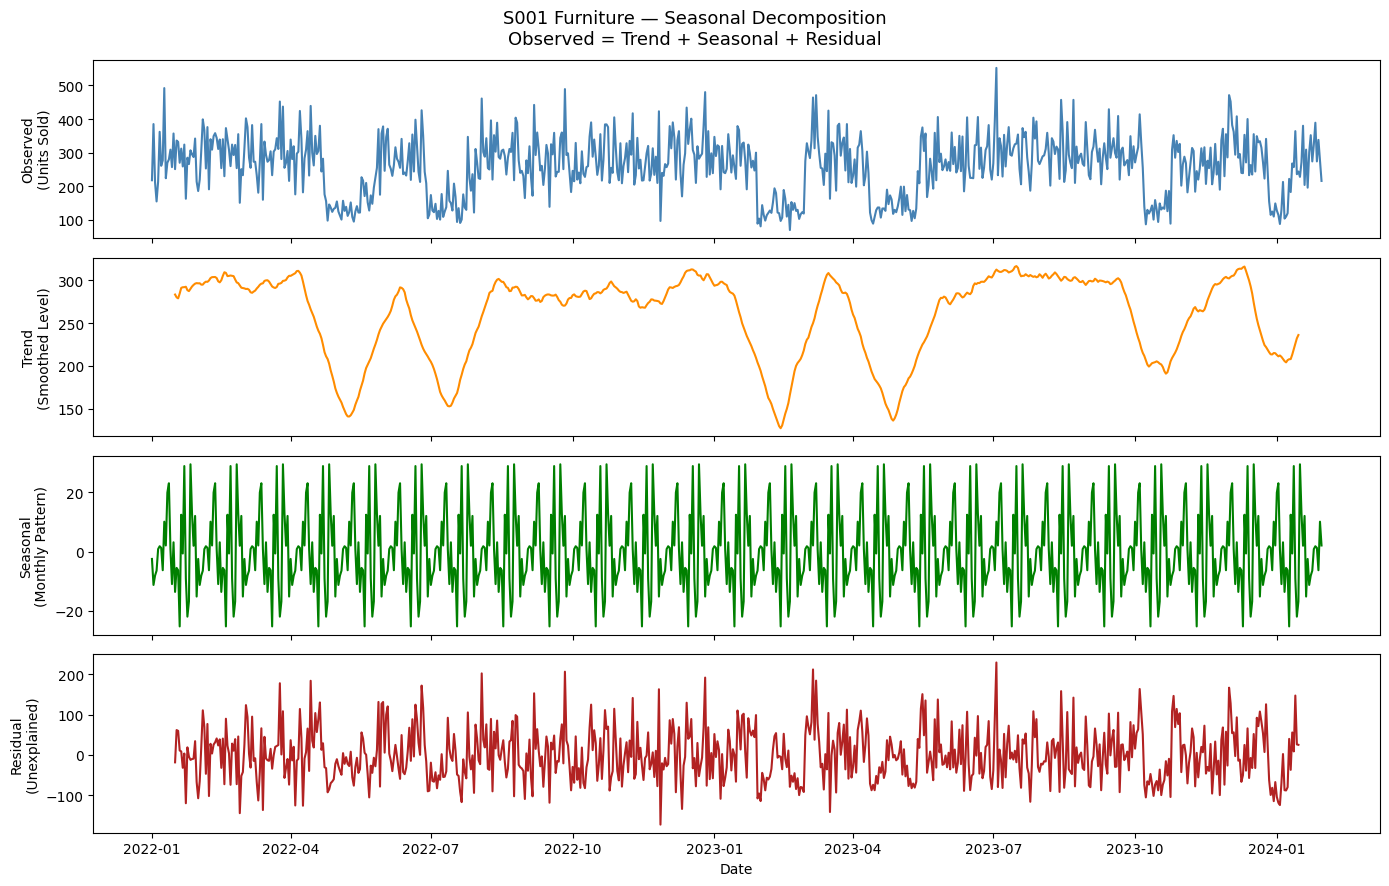

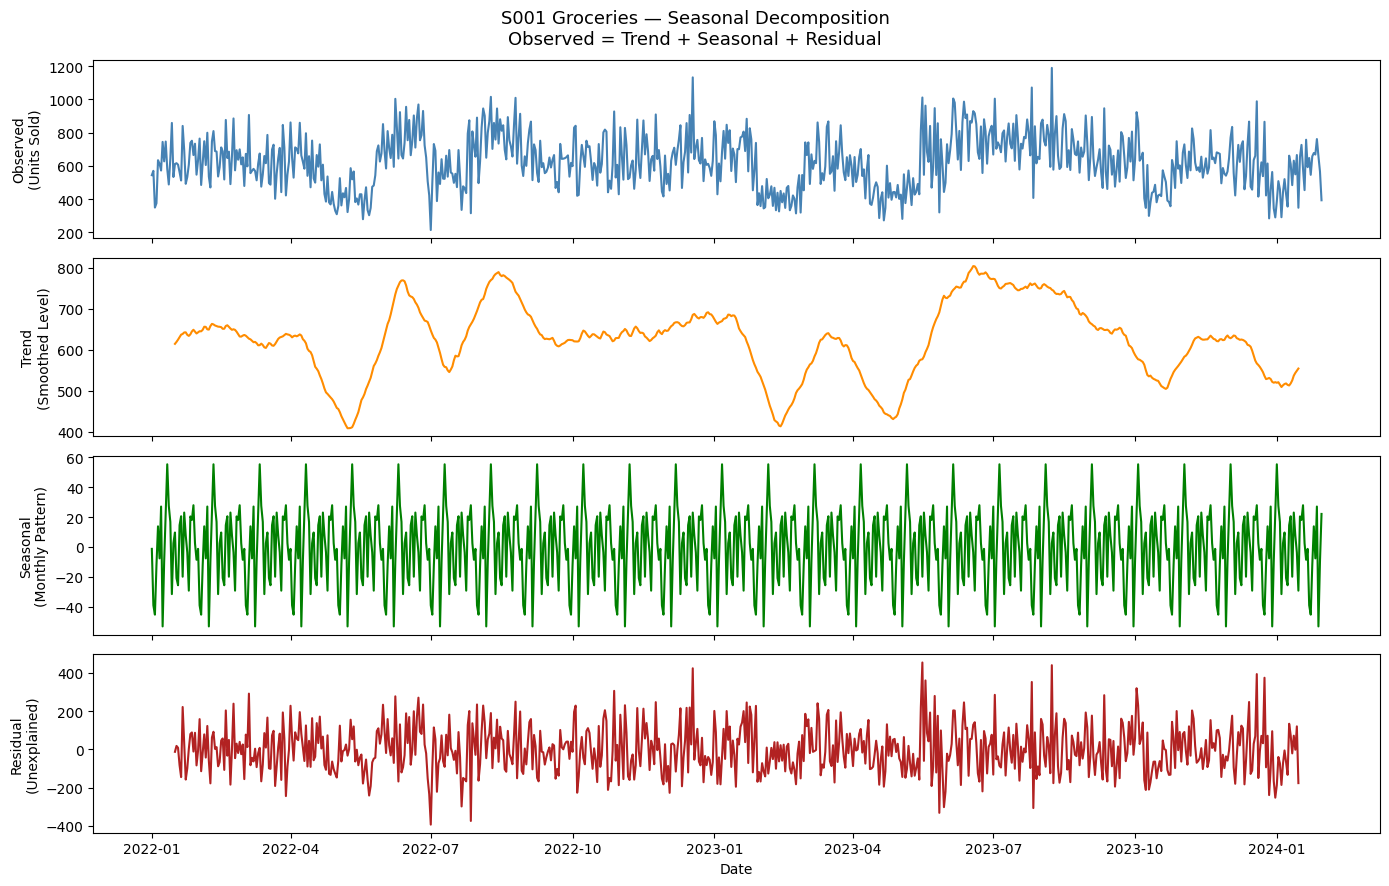

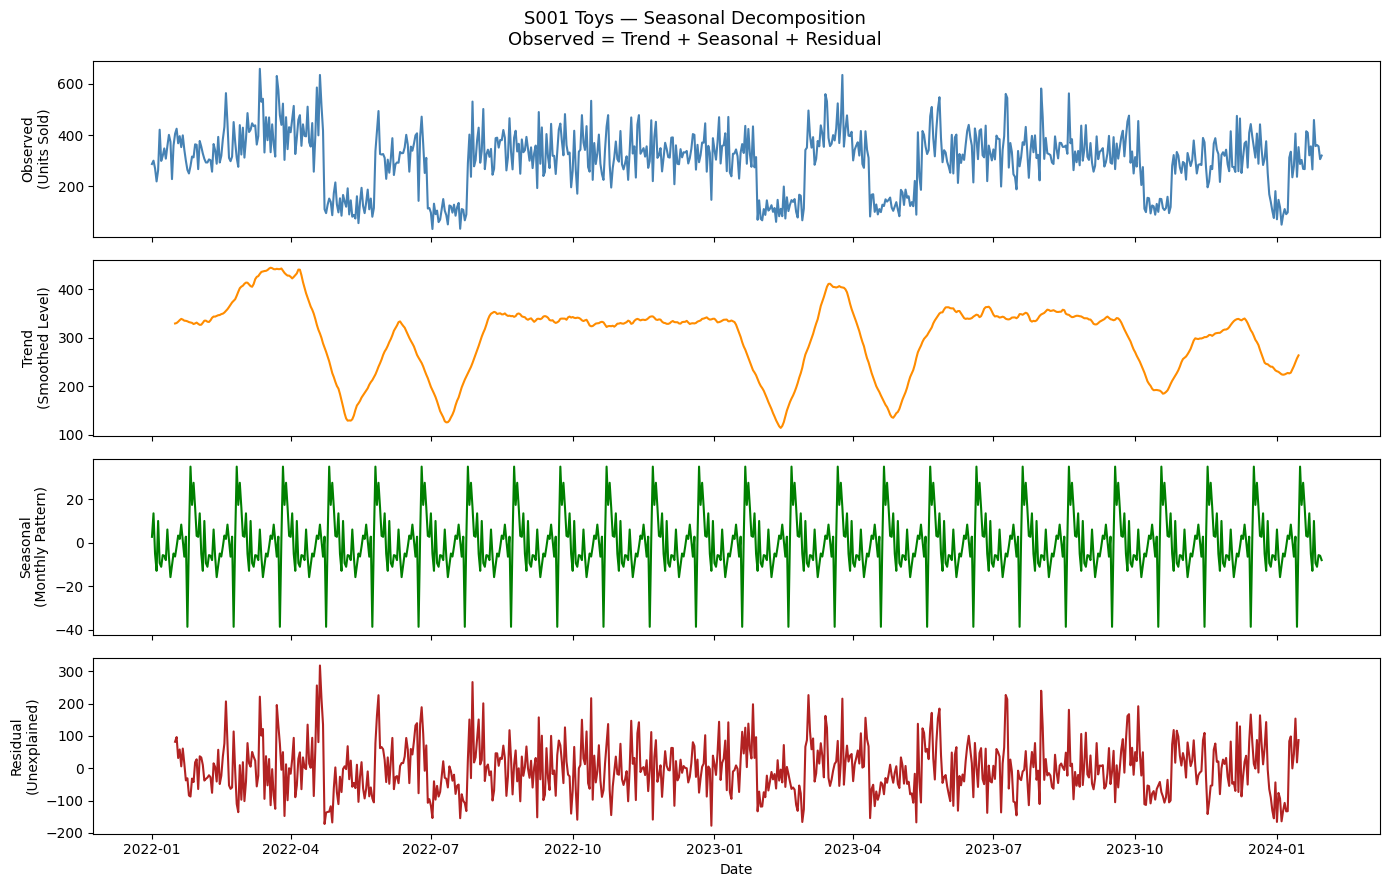

In [27]:
# Representative store-category combinations
representatives = [
    ('S001', 'Clothing'),
    ('S001', 'Electronics'),
    ('S001', 'Furniture'),
    ('S001', 'Groceries'),
    ('S001', 'Toys'),
]

# Ploting decomposition for each representative series
for store, category in representatives:
    # Prepare time series
    ts = (store_cat[(store_cat['Store ID'] == store) &
                    (store_cat['Category'] == category)
        ]
        .set_index('Date')['Units Sold']
        .sort_index()
        .asfreq('D')
    )

    # Seasonal decomposition
    decomposition = seasonal_decompose(
        ts,
        model='additive',
        period=30   # monthly seasonality
    )

    # Plot decomposition
    fig, axes = plt.subplots(
        4, 1,
        figsize=(14, 9),
        sharex=True
    )

    fig.suptitle(
        f'{store} {category} — Seasonal Decomposition\n'
        'Observed = Trend + Seasonal + Residual',
        fontsize=13
    )

    # Observed
    axes[0].plot(
        decomposition.observed,
        color='steelblue'
    )
    axes[0].set_ylabel('Observed\n(Units Sold)')

    # Trend
    axes[1].plot(
        decomposition.trend,
        color='darkorange'
    )
    axes[1].set_ylabel('Trend\n(Smoothed Level)')

    # Seasonal
    axes[2].plot(
        decomposition.seasonal,
        color='green'
    )
    axes[2].set_ylabel('Seasonal\n(Monthly Pattern)')

    # Residual
    axes[3].plot(
        decomposition.resid,
        color='firebrick'
    )
    axes[3].set_ylabel('Residual\n(Unexplained)')
    axes[3].set_xlabel('Date')

    plt.tight_layout()
    plt.show()

- With the change in levels SES with a rolling window with updated information may be most appropriate for count for the drastic change in levels we might see such as in the Furniture and Toys. 
- We see that there is no clear trend, maybe some have got a slight overall decrease like S001 Toys, therefore Holt might be a candidate for this model.
- Seasonality doesnt show strong waves, thus may not have seasonal component and the Holt Winters may not be appropriate. 
- Further note there is no clear multiplitive behaviour with the variance changing with levels so if there is some seasonality it likely to be additive. 

In [28]:
# Function to evaluate model performance, to be used on one model
def evaluate_model(model, hmax, test_ses):
    """
    A helper function that evaluates a given model, and returns the
    squared error against a given test series.
    """
    #Fit Model
    fit_ses = model.fit()
    #Make forecasts
    fc_ses = fit_ses.forecast(hmax)
    #Compute square error
    return np.square(fc_ses-test_ses)

In [29]:
# Check the evaluations of SES, Holt's, and Holt-Winters models on one representative series
store, category = ('S001', 'Clothing')
ts = store_cat[(store_cat['Store ID'] == store) & 
                (store_cat['Category'] == category)].set_index('Date')['Units Sold'].sort_index()

train = ts.iloc[:-HOLDOUT]
test = ts.iloc[-HOLDOUT:]

# SES
modelSES = SimpleExpSmoothing(train)
SESfitted = modelSES.fit()
eval_SES = evaluate_model(modelSES, HOLDOUT, test)

# Trend correction with Holt's method
modelholt = Holt(train)
holtfitted = modelholt.fit()
eval_holt = evaluate_model(modelholt, HOLDOUT, test)

# Holt-Winters method with additive seasonality
modelHW = ExponentialSmoothing(train)
HWfitted = modelHW.fit()
eval_HW = evaluate_model(modelHW, HOLDOUT, test)

#Initialise Results data frame
res = pd.DataFrame({
    'h': range(1, HOLDOUT+1),
    'SES': eval_SES,
    'Holt': eval_holt,
    'HW': eval_HW,
})

print(res)

             h           SES          Holt            HW
2024-01-03   1   3257.187261   9986.485371   3647.024070
2024-01-04   2    253.708419    987.070902    158.997072
2024-01-05   3  16881.344199   6099.146864  16029.941213
2024-01-06   4   3144.043715  12631.117750   3527.242878
2024-01-07   5   2408.038895  12072.191746   2744.774536
2024-01-08   6   2109.402045    374.763396   1815.561320
2024-01-09   7   6388.521489    103.142565   5869.000801
2024-01-10   8    572.560053   2533.045256    424.747538
2024-01-11   9     35.143877   5301.973002      6.808990
2024-01-12  10    572.560053   3516.481555    424.747538
2024-01-13  11   1842.832683   2005.714975   1568.904895
2024-01-14  12   2393.971408   1872.335293   2080.217745
2024-01-15  13   4889.956946    715.871249   4436.812718
2024-01-16  14     16.579334  11075.678800     54.620907
2024-01-17  15     65.153518  12933.678467    129.745674
2024-01-18  16    480.847144   7781.288490    346.309922
2024-01-19  17   5465.382763   

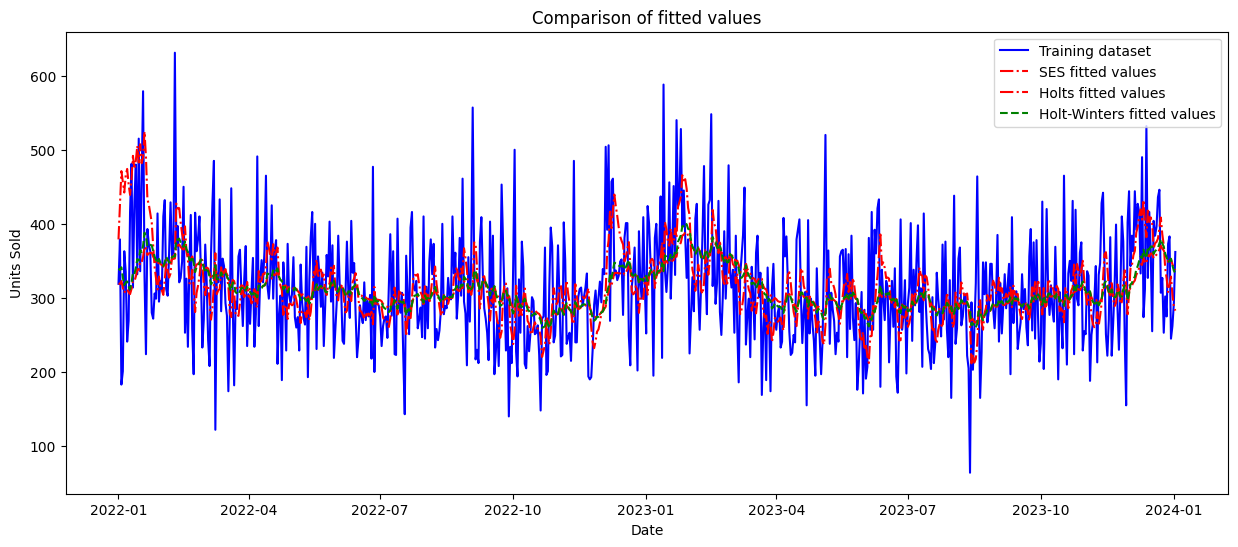

In [30]:
# plotting fitted values together
# Plot all together
plt.figure(figsize=(15,6))
plt.plot(train, 'b-', label = 'Training dataset')
plt.plot(SESfitted.fittedvalues, 'r-.',label = 'SES fitted values')
plt.plot(holtfitted.fittedvalues, 'r-.',label = 'Holts fitted values')
plt.plot(HWfitted.fittedvalues, 'g--', label = 'Holt-Winters fitted values')
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.title("Comparison of fitted values")
plt.legend()
plt.show()


- We see that it is closely fitted with the previous data, however, may be overfitted.
- Thus for forecasting on unseen data, we will use rolling window

In [31]:
# Set window size 30, step 30, and holdout 28 for rolling window evaluation across all series
WINDOW_SIZE = 30
WINDOW_STEP = 30
all_results = []

# For every store-category combination
# perform rolling window evaluation of SES, Holt's, and Holt-Winters models
# select best model, refit on full training set, and evaluate on holdout
for (store, category), group in store_cat.groupby(['Store ID', 'Category']):

    ts = (group.set_index('Date')['Units Sold'].sort_index().asfreq('D'))

    if len(ts) < WINDOW_SIZE + HOLDOUT:
        continue

    # Rolling window evaluation
    model_configs = {
        'SES': lambda x: SimpleExpSmoothing(
            x, initialization_method="estimated"
        ),
        'Holt': lambda x: Holt(
            x, initialization_method="estimated"
        ),
        'Holt-Winters': lambda x: ExponentialSmoothing(
            x,
            trend='add',
            seasonal='add',
            seasonal_periods=7,
            initialization_method="estimated"
        )
    }

    mae_records = []
    best_model_name = None
    best_total_mae = np.inf

    # Roll window forward by WINDOW_STEP days
    for start_idx in range(0, len(ts) - WINDOW_SIZE - HOLDOUT + 1, WINDOW_STEP):
        
        train = ts.iloc[start_idx : start_idx + WINDOW_SIZE]
        test = ts.iloc[start_idx + WINDOW_SIZE : start_idx + WINDOW_SIZE + HOLDOUT]

        if train.isna().any() or test.isna().any() or len(test) < HOLDOUT:
            continue

        for model_name, model_func in model_configs.items():
            try:
                fit = model_func(train).fit(optimized=True)
                forecast = fit.forecast(len(test))
                mae = np.mean(np.abs(test.values - forecast.values))
                mae_records.append({
                    'Model': model_name,
                    'MAE': mae
                })
            except:
                continue

    # Best model based on lowest average MAE across windows
    if mae_records:
        mae_df = pd.DataFrame(mae_records)
        best_model_name = (
            mae_df.groupby('Model')['MAE']
            .mean()
            .sort_values()
            .index[0]
        )
        best_total_mae = mae_df.groupby('Model')['MAE'].mean()[best_model_name]

        # refit best model on full training set
        train_full = ts.iloc[:-HOLDOUT]
        test_full = ts.iloc[-HOLDOUT:]
        
        best_model_func = model_configs[best_model_name]
        final_fit = best_model_func(train_full).fit(optimized=True)
        forecast = final_fit.forecast(HOLDOUT)
        forecast.index = test_full.index

        # Calculate metrics for comparison with max model
        mae = np.mean(np.abs(test_full.values - forecast.values))
        rmse = np.sqrt(np.mean((test_full.values - forecast.values) ** 2))
        mape = np.mean(
            np.abs((test_full.values - forecast.values) /
                   np.where(test_full.values == 0, 1, test_full.values))
        ) * 100

        # save results for this store-category combination for SES family models
        all_results.append({
            'Store': store,
            'Category': category,
            'Best Model': best_model_name,
            'MAE (Avg)': best_total_mae,
            'MAE': mae,
            'RMSE': rmse,
            'MAPE': mape,
            'Forecast': forecast
        })

        print(f"✓ {store} {category}  Best={best_model_name}  MAE={mae:.2f}")

results_df = pd.DataFrame(all_results)
print("\n" + results_df.to_string(index=False))

✓ S001 Clothing  Best=SES  MAE=50.42
✓ S001 Electronics  Best=SES  MAE=99.24
✓ S001 Furniture  Best=SES  MAE=115.36
✓ S001 Groceries  Best=SES  MAE=143.05
✓ S001 Toys  Best=SES  MAE=162.02
✓ S002 Clothing  Best=SES  MAE=81.38
✓ S002 Electronics  Best=SES  MAE=84.04
✓ S002 Furniture  Best=SES  MAE=21.14
✓ S002 Groceries  Best=SES  MAE=168.18
✓ S002 Toys  Best=SES  MAE=111.74
✓ S003 Clothing  Best=SES  MAE=50.21
✓ S003 Electronics  Best=SES  MAE=70.08
✓ S003 Furniture  Best=SES  MAE=98.68
✓ S003 Groceries  Best=SES  MAE=236.31
✓ S003 Toys  Best=SES  MAE=132.31
✓ S004 Clothing  Best=SES  MAE=95.91
✓ S004 Electronics  Best=SES  MAE=27.85
✓ S004 Furniture  Best=SES  MAE=189.49
✓ S004 Groceries  Best=SES  MAE=149.42
✓ S005 Clothing  Best=SES  MAE=25.46
✓ S005 Electronics  Best=SES  MAE=52.12
✓ S005 Furniture  Best=SES  MAE=87.23
✓ S005 Groceries  Best=SES  MAE=248.84
✓ S005 Toys  Best=SES  MAE=185.87

Store    Category Best Model  MAE (Avg)        MAE       RMSE      MAPE                    

Found that all had SES as best model based on MAE

In [32]:
results = []

total_abs_error_5 = 0.0
total_abs_actual_5 = 0.0
total_sq_error_5 = 0.0
total_count_5 = 0

total_abs_error_28 = 0.0
total_abs_actual_28 = 0.0
total_sq_error_28 = 0.0
total_count_28 = 0

for (store, category), group in store_cat.groupby(["Store ID", "Category"]):
    ts = (
        group
        .set_index("Date")["Units Sold"]
        .sort_index()
        .asfreq("D")
        .interpolate(method="linear")
    )

    if len(ts) < HOLDOUT + 5:
        continue

    train = ts.iloc[:-HOLDOUT]
    test = ts.iloc[-HOLDOUT:]

    ses_fit = SimpleExpSmoothing(
        train,
        initialization_method="estimated"
    ).fit(optimized=True)

    forecast_28 = ses_fit.forecast(HOLDOUT)
    forecast_5 = forecast_28.iloc[:5]

    actual_5 = test.iloc[:5]
    actual_28 = test

    error_5 = actual_5.values - forecast_5.values
    error_28 = actual_28.values - forecast_28.values

    rmse_5 = np.sqrt(np.mean(error_5 ** 2))
    mape_5 = np.mean(
        np.abs(error_5 / np.where(actual_5.values == 0, 1, actual_5.values))
    ) * 100
    wmape_5 = np.sum(np.abs(error_5)) / np.sum(np.abs(actual_5.values)) * 100

    rmse_28 = np.sqrt(np.mean(error_28 ** 2))
    mape_28 = np.mean(
        np.abs(error_28 / np.where(actual_28.values == 0, 1, actual_28.values))
    ) * 100
    wmape_28 = np.sum(np.abs(error_28)) / np.sum(np.abs(actual_28.values)) * 100

    results.append({
        "Store": store,
        "Category": category,
        "RMSE_5d": rmse_5,
        "MAPE_5d": mape_5,
        "WMAPE_5d": wmape_5,
        "RMSE_28d": rmse_28,
        "MAPE_28d": mape_28,
        "WMAPE_28d": wmape_28
    })

    total_abs_error_5 += np.sum(np.abs(error_5))
    total_abs_actual_5 += np.sum(np.abs(actual_5.values))
    total_sq_error_5 += np.sum(error_5 ** 2)
    total_count_5 += len(error_5)

    total_abs_error_28 += np.sum(np.abs(error_28))
    total_abs_actual_28 += np.sum(np.abs(actual_28.values))
    total_sq_error_28 += np.sum(error_28 ** 2)
    total_count_28 += len(error_28)

ses_metrics_df = pd.DataFrame(results).round(2)

average_metrics = pd.DataFrame([{
    "Store": "ALL",
    "Category": "AVERAGE",
    "RMSE_5d": ses_metrics_df["RMSE_5d"].mean(),
    "MAPE_5d": ses_metrics_df["MAPE_5d"].mean(),
    "WMAPE_5d": ses_metrics_df["WMAPE_5d"].mean(),
    "RMSE_28d": ses_metrics_df["RMSE_28d"].mean(),
    "MAPE_28d": ses_metrics_df["MAPE_28d"].mean(),
    "WMAPE_28d": ses_metrics_df["WMAPE_28d"].mean()
}]).round(2)

display(ses_metrics_df)
display(average_metrics)

,Store,Category,RMSE_5d,MAPE_5d,WMAPE_5d,RMSE_28d,MAPE_28d,WMAPE_28d
0,S001,Clothing,72.26,21.65,18.20,61.25,16.55,15.40
1,S001,Electronics,38.05,26.34,19.56,122.23,36.76,40.48
2,S001,Furniture,45.69,33.21,31.60,133.43,43.37,47.01
3,S001,Groceries,79.55,15.65,12.65,167.19,24.28,25.38
4,S001,Toys,47.29,58.65,44.73,181.97,57.56,58.44
5,S002,Clothing,49.24,9.05,8.79,96.07,17.49,16.46
6,S002,Electronics,34.63,23.79,20.22,102.29,32.51,35.60
7,S002,Furniture,20.47,63.45,57.91,28.71,37.34,34.94
8,S002,Groceries,66.95,10.75,10.33,202.57,20.03,21.91
9,S002,Toys,25.35,30.16,24.84,138.35,47.42,54.57


,Store,Category,RMSE_5d,MAPE_5d,WMAPE_5d,RMSE_28d,MAPE_28d,WMAPE_28d
0,ALL,AVERAGE,50.63,27.63,22.9,133.77,34.36,35.83



Simple Exponential Smoothing Equation:
Forecast_t = α * Actual_(t-1) + (1-α) * Forecast_(t-1)
α (smoothing level) = 0.063


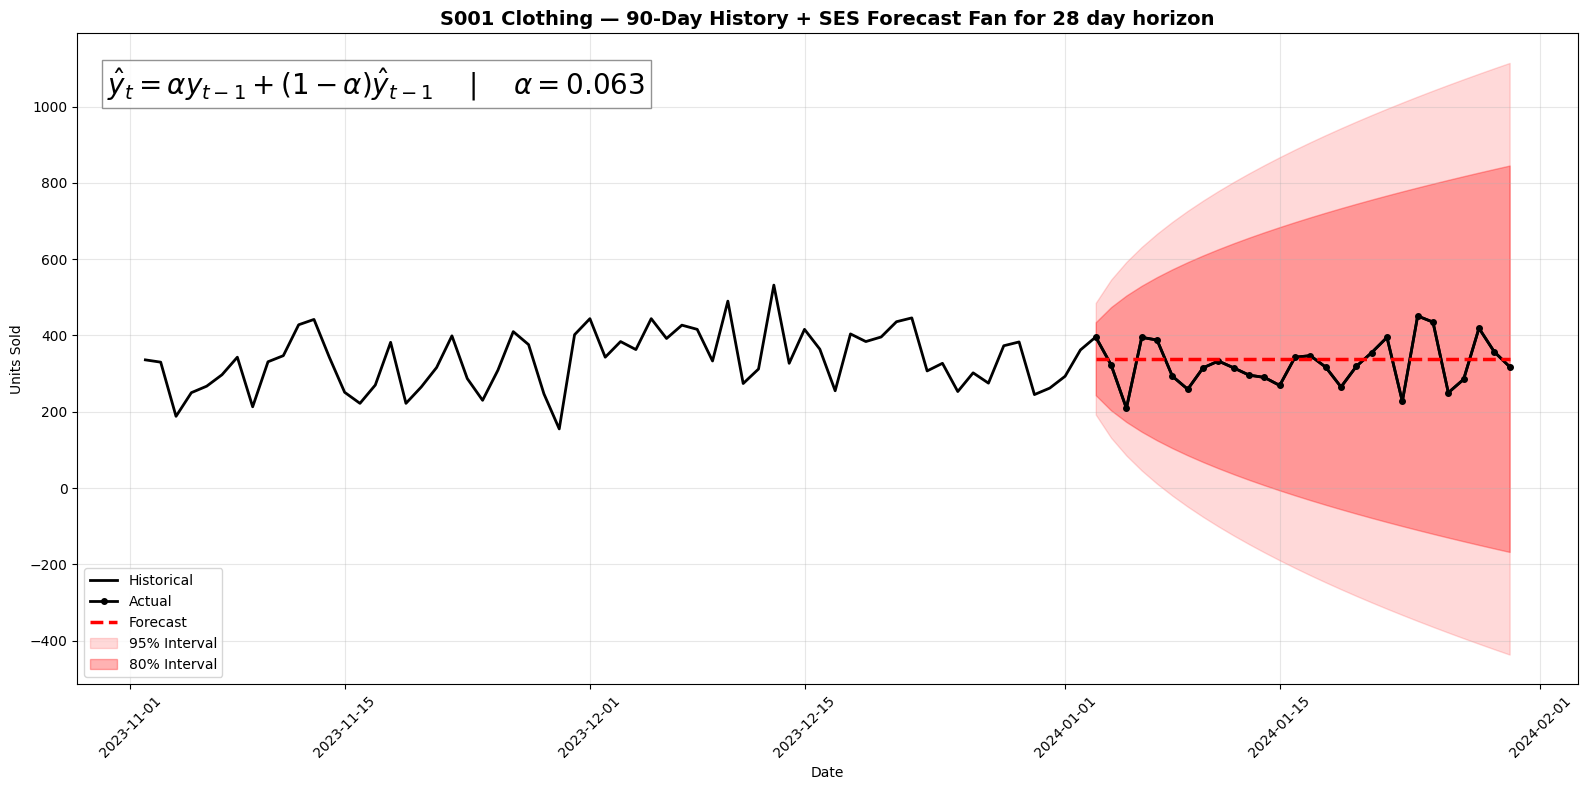

In [33]:
# Plot last 90 Days + forecast with prediction interval fan
# Including SES forecasting equation in chart and console

# Candidate series 
selected_series = [('S001', 'Clothing')]

fig, axes = plt.subplots(len(selected_series), 1, figsize=(16, 8))

if len(selected_series) == 1:
    axes = [axes]

for idx, (store, category) in enumerate(selected_series):

    ax = axes[idx]
    ts = (store_cat[(store_cat['Store ID'] == store) &(store_cat['Category'] == category)]
        .set_index('Date')['Units Sold']
        .sort_index()
    )

    train = ts.iloc[:-HOLDOUT]
    test = ts.iloc[-HOLDOUT:]

    # Last 90 days of actuals
    last_90 = ts.last('90D')

    # Fit SES model
    model = SimpleExpSmoothing(train).fit()

    forecast = model.forecast(HOLDOUT)

    # Extract smoothing parameter
    alpha = model.model.params['smoothing_level']

    # SES Equation
    equation = (
        rf"$\hat{{y}}_t = \alpha y_{{t-1}} + (1-\alpha)\hat{{y}}_{{t-1}}$"
        rf"    |    $\alpha = {alpha:.3f}$"
    )

    # Print equation below chart
    print("\nSimple Exponential Smoothing Equation:")
    print(f"Forecast_t = α * Actual_(t-1) + (1-α) * Forecast_(t-1)")
    print(f"α (smoothing level) = {alpha:.3f}")

    # Prediction intervals
    residuals = train - model.fittedvalues
    sigma = residuals.std()

    h = np.arange(1, HOLDOUT + 1)
    interval_scale = np.sqrt(h)

    # 80% interval
    lower_80 = forecast - 1.28 * sigma * interval_scale
    upper_80 = forecast + 1.28 * sigma * interval_scale

    # 95% interval
    lower_95 = forecast - 1.96 * sigma * interval_scale
    upper_95 = forecast + 1.96 * sigma * interval_scale

    # Plot historical data
    ax.plot(
        last_90.index,
        last_90.values,
        color='black',
        linewidth=2,
        label='Historical'
    )

    # Actual holdout
    ax.plot(
        test.index,
        test.values,
        'ko-',
        linewidth=2,
        markersize=4,
        label='Actual'
    )

    # Forecast
    ax.plot(
        forecast.index,
        forecast.values,
        color='red',
        linestyle='--',
        linewidth=2.5,
        label='Forecast'
    )

    # Forecast fan intervals
    ax.fill_between(
        forecast.index,
        lower_95,
        upper_95,
        color='red',
        alpha=0.15,
        label='95% Interval'
    )

    ax.fill_between(
        forecast.index,
        lower_80,
        upper_80,
        color='red',
        alpha=0.30,
        label='80% Interval'
    )

    # Add equation inside figure
    ax.text(
        0.02,
        0.95,
        equation,
        transform=ax.transAxes,
        fontsize=20,
        verticalalignment='top',
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray')
    )

    ax.set_title(
        f'{store} {category} — 90-Day History + SES Forecast Fan for 28 day horizon',
        fontsize=14,
        fontweight='bold'
    )

    ax.set_xlabel('Date')
    ax.set_ylabel('Units Sold')

    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')

    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()